<a href="https://colab.research.google.com/github/beena24/Research_works/blob/main/ILD_radiomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load the data
data = pd.read_csv('/content/drive/MyDrive/combined-features.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Train a Random Forest classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Optional: Tune hyperparameters using GridSearchCV
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30],
#     'min_samples_split': [2, 5, 10]
# }
# grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
# grid_search.fit(X_train, y_train)
# print(grid_search.best_params_)
# best_model = grid_search.best_estimator_
# y_pred_best = best_model.predict(X_test)
# print(classification_report(y_test, y_pred_best))
# print(confusion_matrix(y_test, y_pred_best))



class-label
1    553
2    428
4    215
3    148
0    105
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       111
           1       0.87      0.82      0.84       110
           2       0.89      0.86      0.88       111
           3       0.93      0.94      0.93       111
           4       0.93      0.96      0.95       110

    accuracy                           0.92       553
   macro avg       0.91      0.91      0.91       553
weighted avg       0.91      0.92      0.91       553

[[110   0   0   1   0]
 [  4  90   9   4   3]
 [  1   9  96   3   2]
 [  0   3   1 104   3]
 [  0   2   2   0 106]]


In [ ]:
!pip install shap lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 17.8 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b794c256a82bff4adbdf548117a27822851e5dab94ae265b5c61dc07d489b394
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


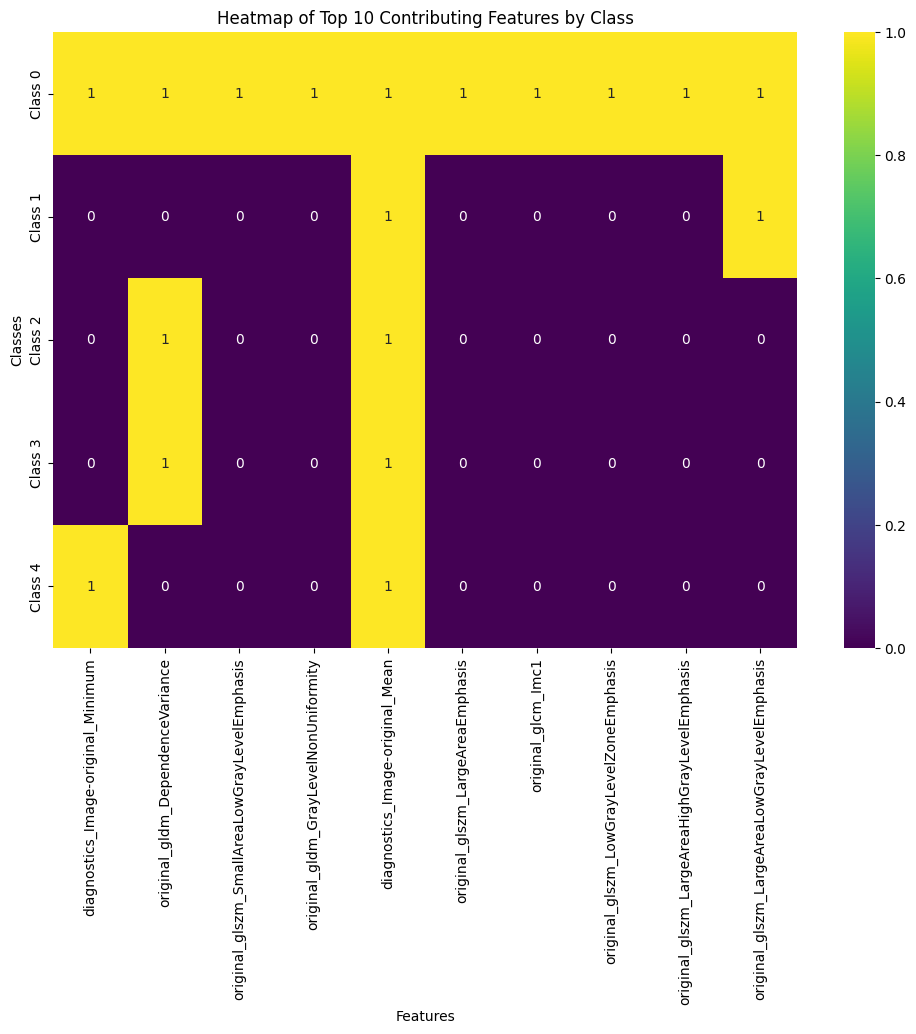

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Create a matrix of feature importances
feature_names = list(top_features_dict[0])
importance_matrix = np.zeros((len(top_features_dict), len(feature_names)))

for class_index, features in top_features_dict.items():
    for i, feature in enumerate(features):
        if feature in feature_names:
            importance_matrix[class_index, feature_names.index(feature)] = 1

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(importance_matrix, cmap='viridis', annot=True, xticklabels=feature_names, yticklabels=[f'Class {i}' for i in range(len(top_features_dict))])
plt.title('Heatmap of Top 10 Contributing Features by Class')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.show()


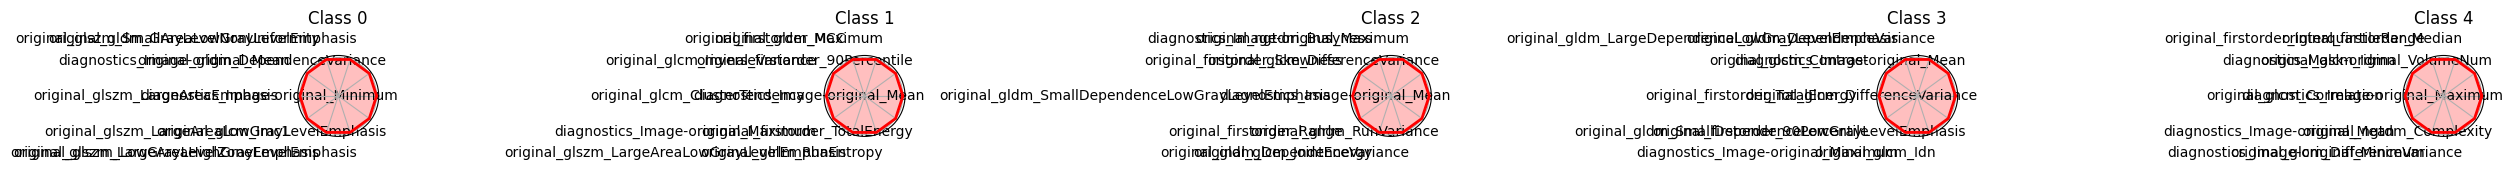

In [ ]:
from math import pi
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_radar_chart(features, values, title, ax):
    num_vars = len(features)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    ax.fill(angles, values, color='red', alpha=0.25)
    ax.plot(angles, values, color='red', linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_title(title)

# Create radar plots for each class
fig, axes = plt.subplots(1, 5, subplot_kw=dict(polar=True), figsize=(25, 5))

# Iterate over axes and class indices, accessing features from the dictionary
for class_index, ax in enumerate(axes):
    features = top_features_dict[class_index]  # Get features for current class
    values = [1] * len(features)
    plot_radar_chart(features, values, f'Class {class_index}', ax)

plt.tight_layout()
plt.show()

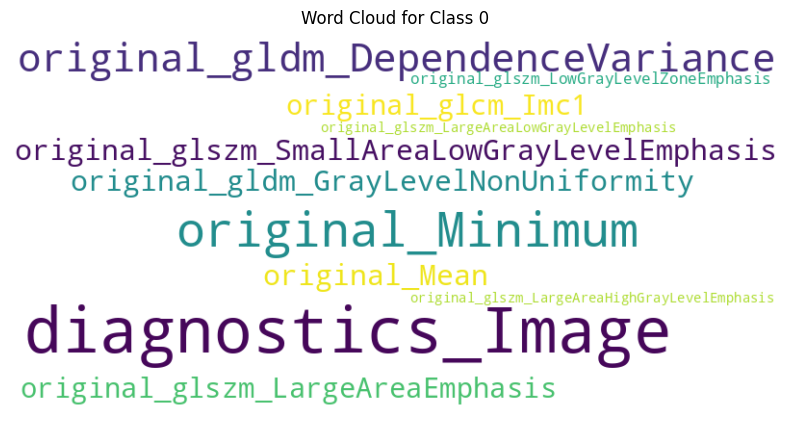

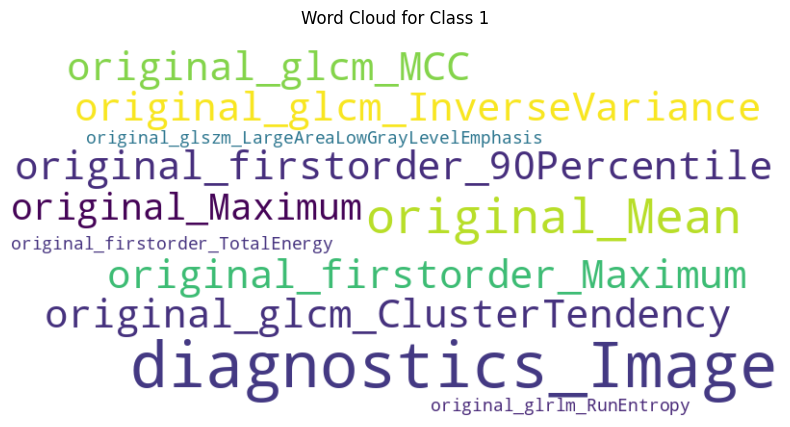

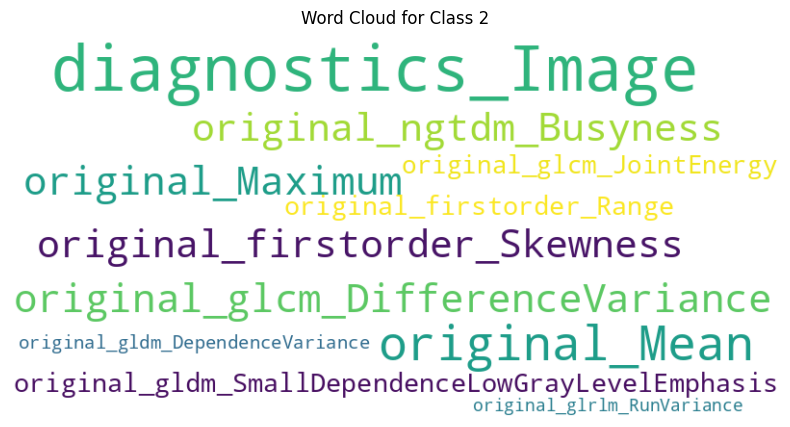

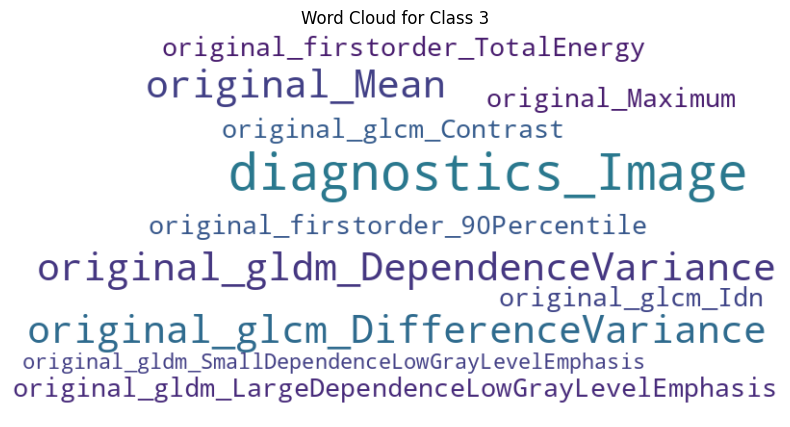

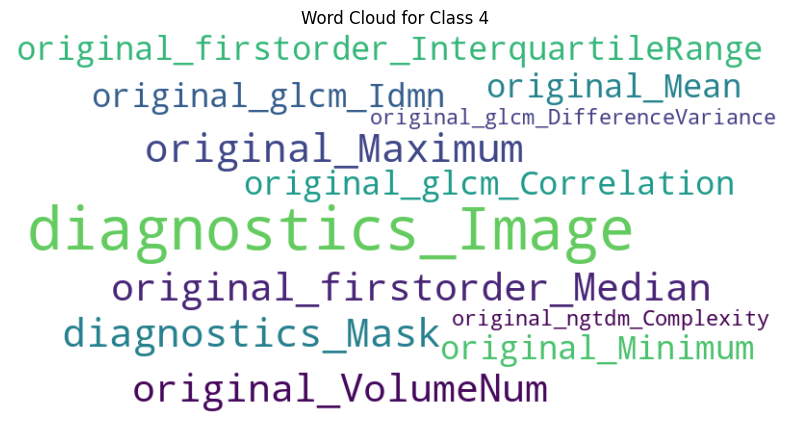

In [ ]:
from wordcloud import WordCloud

# Create a word cloud for each class
for class_index, features in top_features_dict.items():
    text = ' '.join(features)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Class {class_index}')
    plt.show()


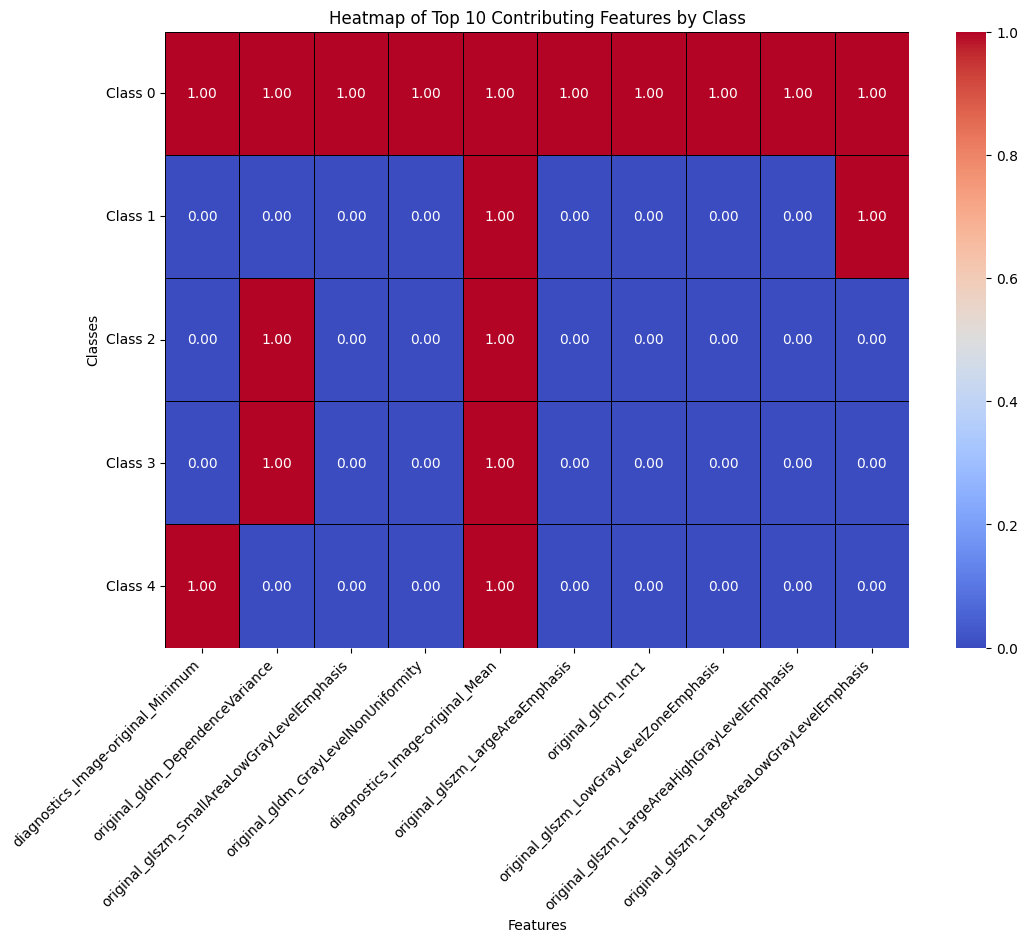

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for the heatmap
heatmap_data = pd.DataFrame(importance_matrix, columns=feature_names, index=[f'Class {i}' for i in range(len(top_features_dict))])

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', linecolor='black', cbar=True)
plt.title('Heatmap of Top 10 Contributing Features by Class')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


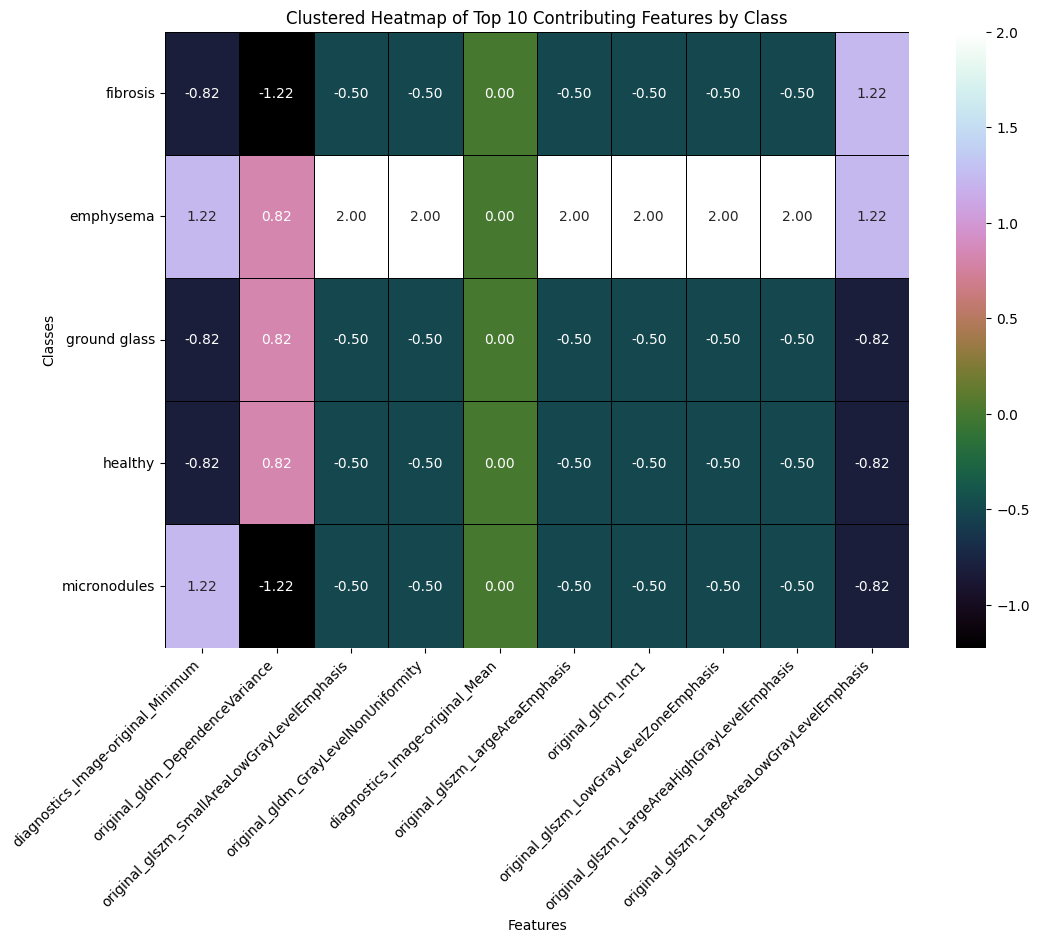

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardize the feature importance matrix
scaler = StandardScaler()
scaled_importance_matrix = scaler.fit_transform(importance_matrix)

# Perform clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_importance_matrix)

# Define class names
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']

# Create a DataFrame for the heatmap with clustering
heatmap_data = pd.DataFrame(scaled_importance_matrix, columns=feature_names, index=class_names)
heatmap_data['Cluster'] = clusters
heatmap_data = heatmap_data.sort_values('Cluster')

# Plot the heatmap with custom palette
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data.drop('Cluster', axis=1), cmap='cubehelix', annot=True, linewidths=0.5, fmt='.2f', linecolor='black', cbar=True)
plt.title('Clustered Heatmap of Top 10 Contributing Features by Class')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


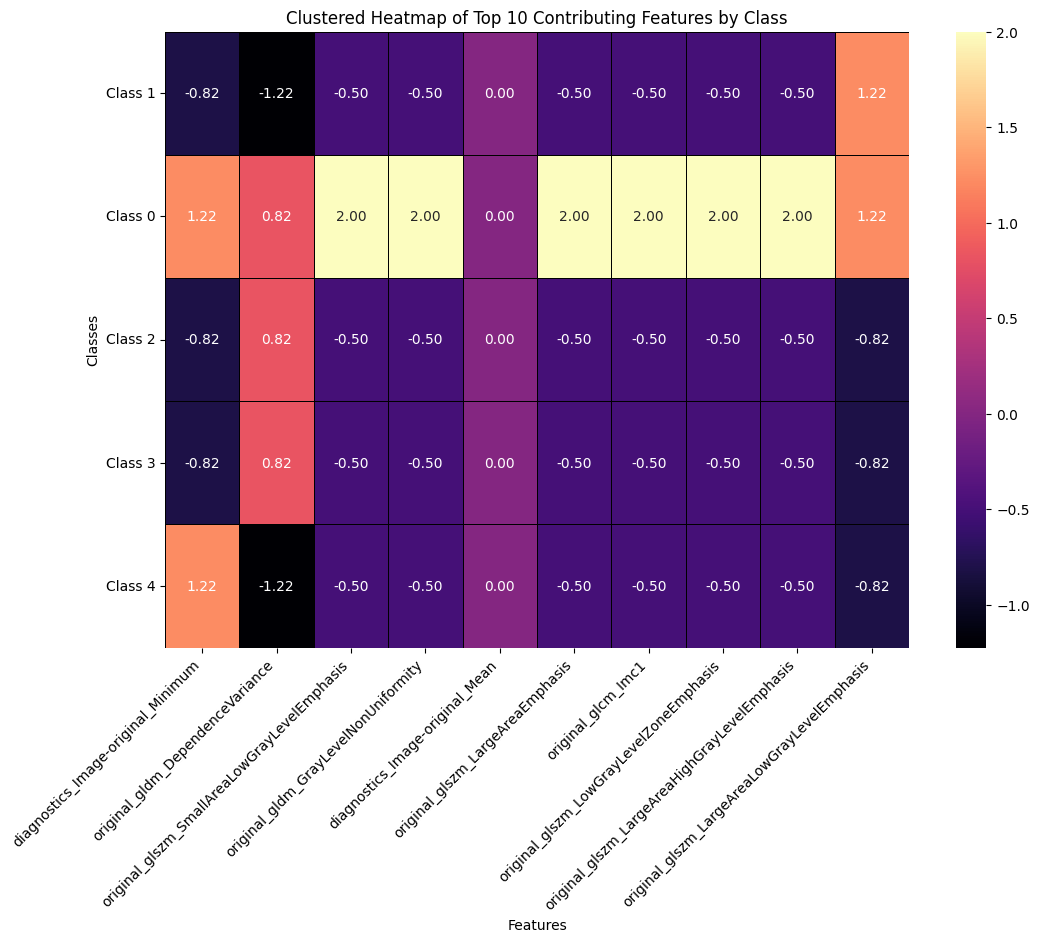

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardize the feature importance matrix
scaler = StandardScaler()
scaled_importance_matrix = scaler.fit_transform(importance_matrix)

# Perform clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_importance_matrix)

# Create a DataFrame for the heatmap with clustering
heatmap_data = pd.DataFrame(scaled_importance_matrix, columns=feature_names, index=[f'Class {i}' for i in range(len(top_features_dict))])
heatmap_data['Cluster'] = clusters
heatmap_data = heatmap_data.sort_values('Cluster')

# Plot the heatmap with custom palette
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data.drop('Cluster', axis=1), cmap='magma', annot=True, linewidths=0.5, fmt='.2f', linecolor='black', cbar=True)
plt.title('Clustered Heatmap of Top 10 Contributing Features by Class')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Create a DataFrame for the heatmap
heatmap_data = pd.DataFrame(importance_matrix, columns=feature_names, index=[f'Class {i}' for i in range(len(top_features_dict))])

# Convert DataFrame to long format for Plotly
heatmap_long = heatmap_data.reset_index().melt(id_vars='index', var_name='Feature', value_name='Importance')
heatmap_long.rename(columns={'index': 'Class'}, inplace=True)

# Plot the interactive heatmap
fig = px.imshow(importance_matrix, labels=dict(x="Feature", y="Class", color="Importance"),
                x=feature_names, y=[f'Class {i}' for i in range(len(top_features_dict))],
                color_continuous_scale='viridis', text_auto=True)
fig.update_layout(title='Interactive Heatmap of Top 10 Contributing Features by Class')
fig.show()


In [ ]:
import plotly.graph_objects as go

# Create a heatmap
heatmap = go.Heatmap(z=importance_matrix, x=feature_names, y=[f'Class {i}' for i in range(len(top_features_dict))],
                     colorscale='Viridis', colorbar=dict(title='Importance'))

# Create the layout
layout = go.Layout(title='Custom Interactive Heatmap of Top 10 Contributing Features by Class',
                   xaxis=dict(title='Features'),
                   yaxis=dict(title='Classes'),
                   autosize=True)

# Plot the heatmap
fig = go.Figure(data=[heatmap], layout=layout)
fig.show()


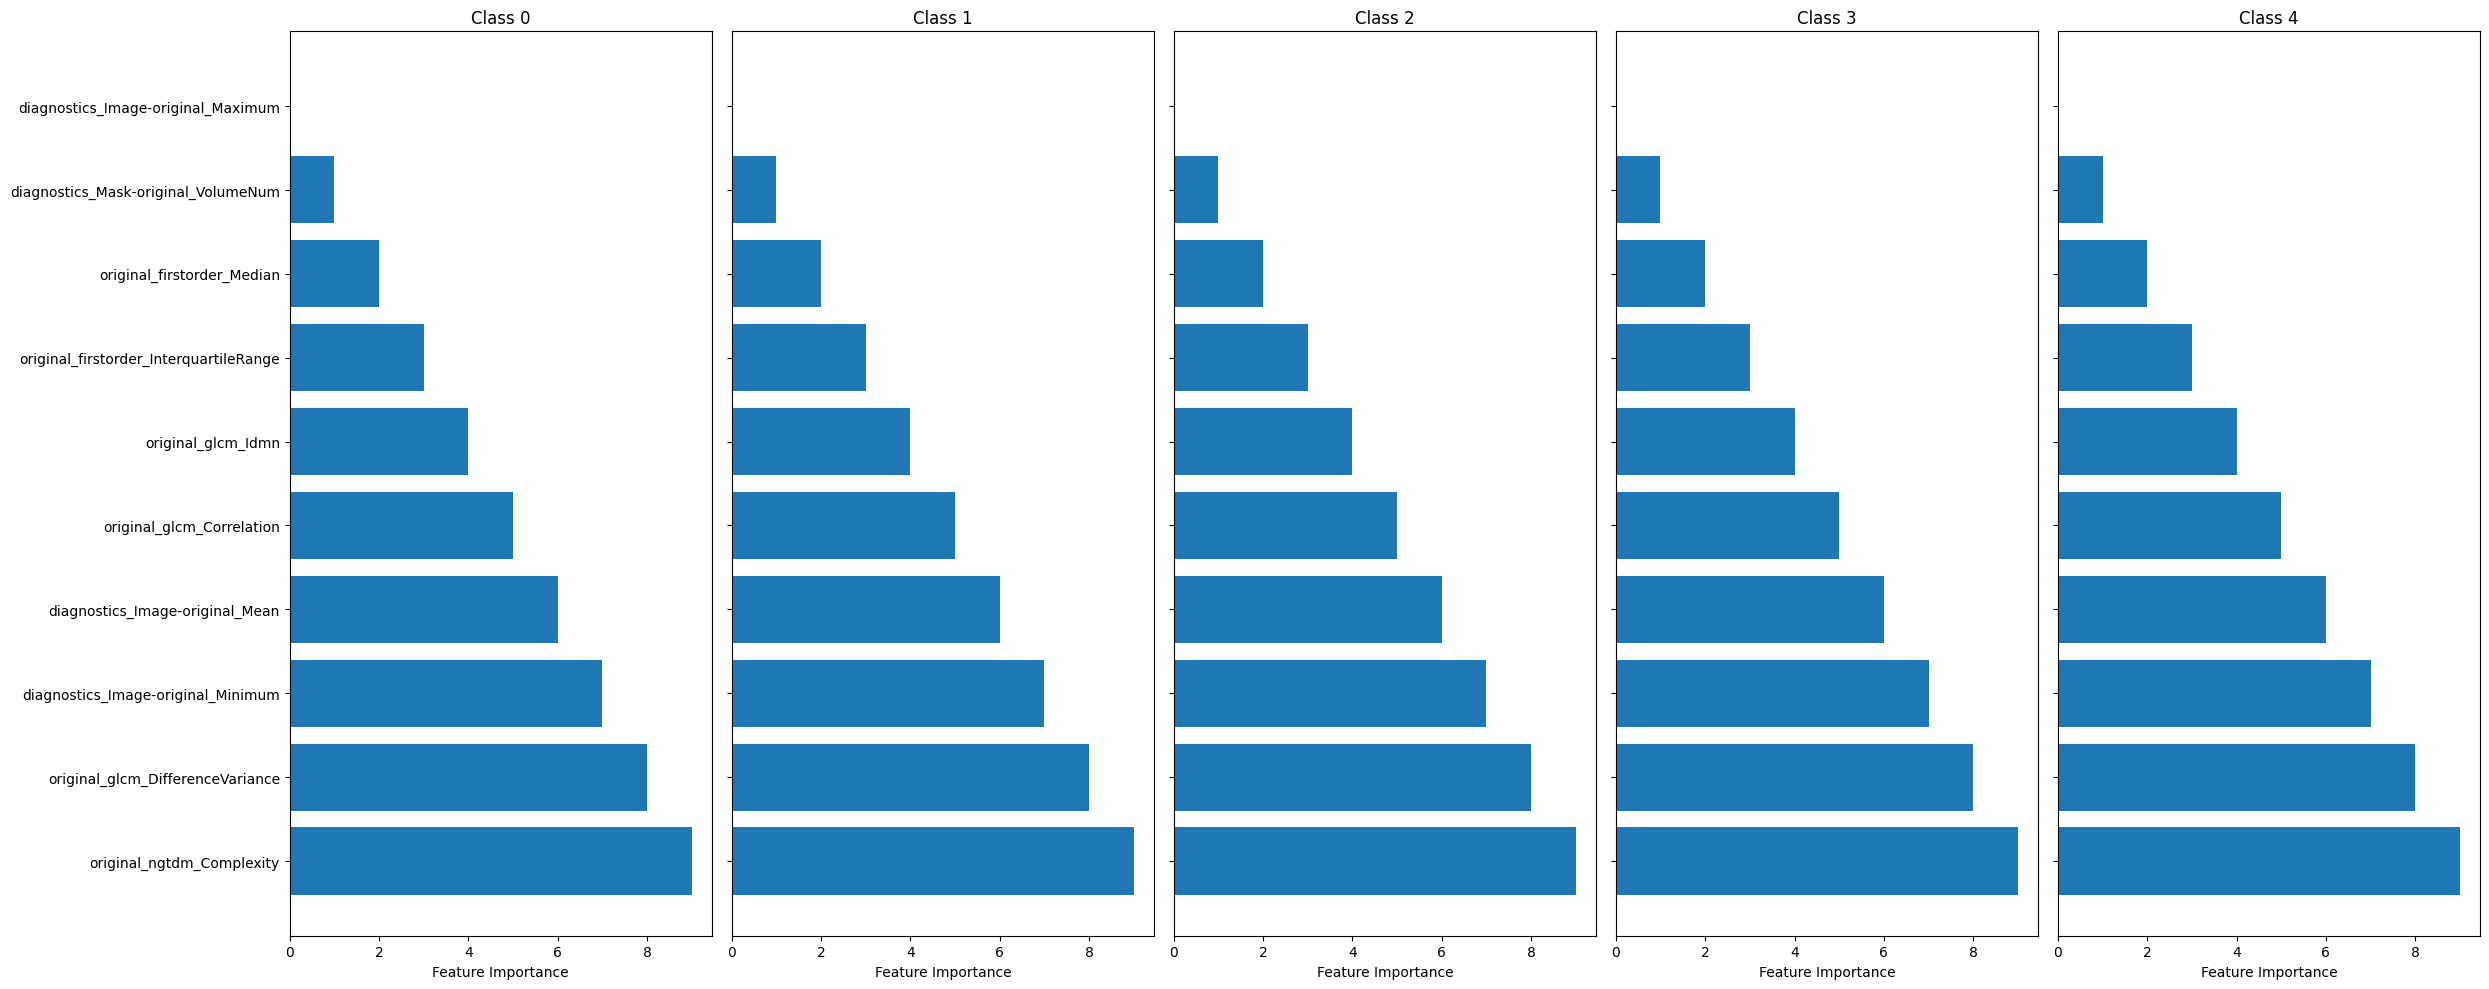

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the top 10 features for each class
top_features_dict = {
    0: [
        'diagnostics_Image-original_Minimum',
        'original_gldm_DependenceVariance',
        'original_glszm_SmallAreaLowGrayLevelEmphasis',
        'original_gldm_GrayLevelNonUniformity',
        'diagnostics_Image-original_Mean',
        'original_glszm_LargeAreaEmphasis',
        'original_glcm_Imc1',
        'original_glszm_LowGrayLevelZoneEmphasis',
        'original_glszm_LargeAreaHighGrayLevelEmphasis',
        'original_glszm_LargeAreaLowGrayLevelEmphasis'
    ],
    1: [
        'diagnostics_Image-original_Mean',
        'original_firstorder_90Percentile',
        'original_firstorder_Maximum',
        'original_glcm_MCC',
        'original_glcm_InverseVariance',
        'original_glcm_ClusterTendency',
        'diagnostics_Image-original_Maximum',
        'original_glszm_LargeAreaLowGrayLevelEmphasis',
        'original_glrlm_RunEntropy',
        'original_firstorder_TotalEnergy'
    ],
    2: [
        'diagnostics_Image-original_Mean',
        'original_glcm_DifferenceVariance',
        'diagnostics_Image-original_Maximum',
        'original_ngtdm_Busyness',
        'original_firstorder_Skewness',
        'original_gldm_SmallDependenceLowGrayLevelEmphasis',
        'original_firstorder_Range',
        'original_glcm_JointEnergy',
        'original_gldm_DependenceVariance',
        'original_glrlm_RunVariance'
    ],
    3: [
        'original_glcm_DifferenceVariance',
        'diagnostics_Image-original_Mean',
        'original_gldm_DependenceVariance',
        'original_gldm_LargeDependenceLowGrayLevelEmphasis',
        'original_glcm_Contrast',
        'original_firstorder_TotalEnergy',
        'original_firstorder_90Percentile',
        'diagnostics_Image-original_Maximum',
        'original_glcm_Idn',
        'original_gldm_SmallDependenceLowGrayLevelEmphasis'
    ],
    4: [
        'diagnostics_Image-original_Maximum',
        'diagnostics_Mask-original_VolumeNum',
        'original_firstorder_Median',
        'original_firstorder_InterquartileRange',
        'original_glcm_Idmn',
        'original_glcm_Correlation',
        'diagnostics_Image-original_Mean',
        'diagnostics_Image-original_Minimum',
        'original_glcm_DifferenceVariance',
        'original_ngtdm_Complexity'
    ]
}

# Function to plot top features for a given class
def plot_top_features(ax, class_index, features):
    y_pos = np.arange(len(features))
    ax.barh(y_pos, range(len(features)), align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Class {class_index}')
    ax.invert_yaxis()  # Invert y-axis to have the highest importance at the top

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(25, 10), sharey=True)

# Plot top features for each class
for class_index, (ax, features) in enumerate(zip(axes, top_features_dict.values())):
    plot_top_features(ax, class_index, features)

plt.tight_layout()
plt.show()


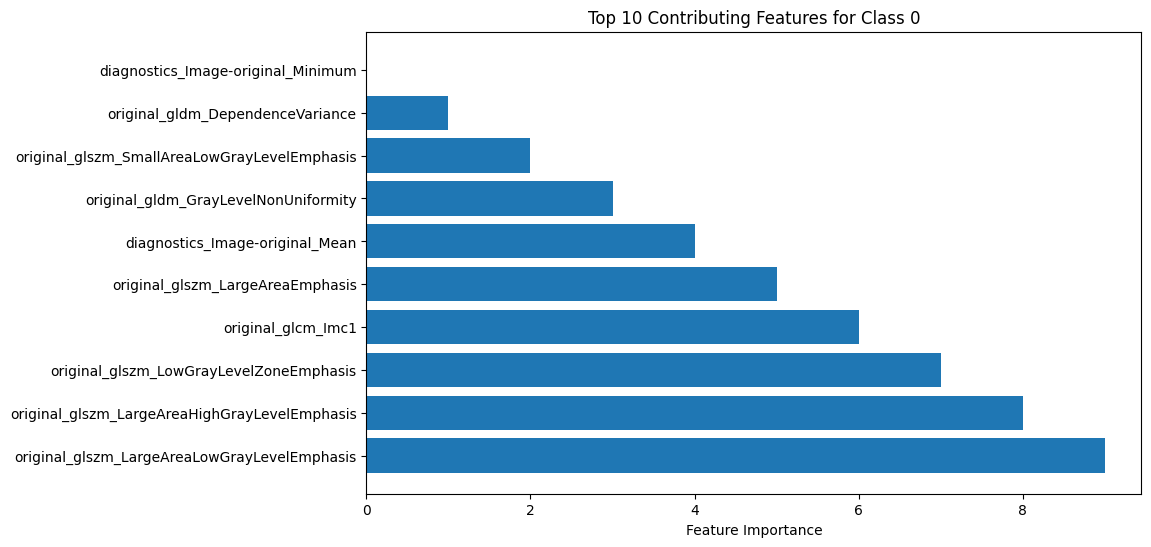

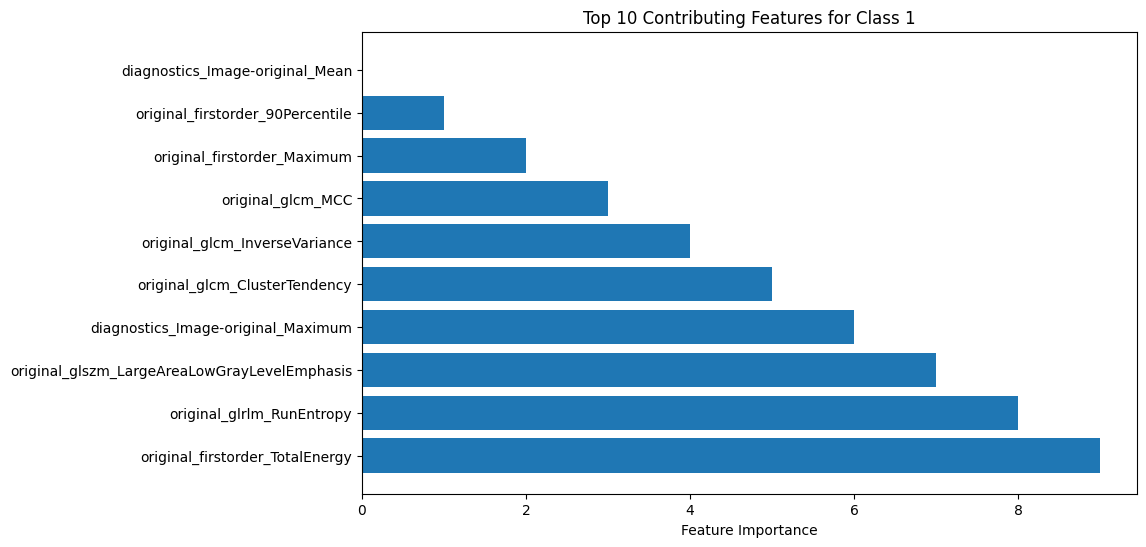

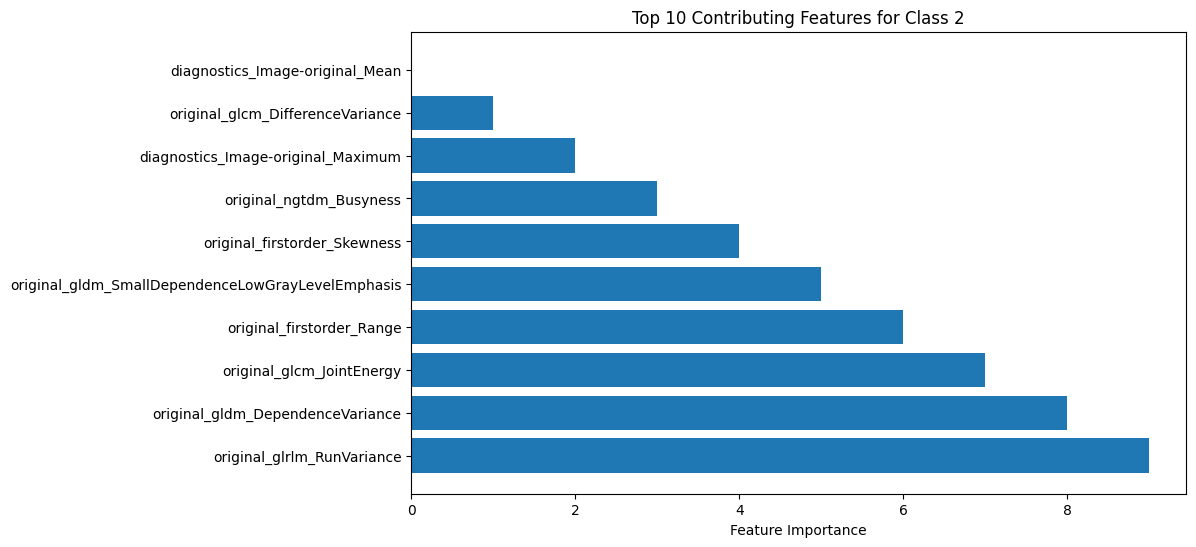

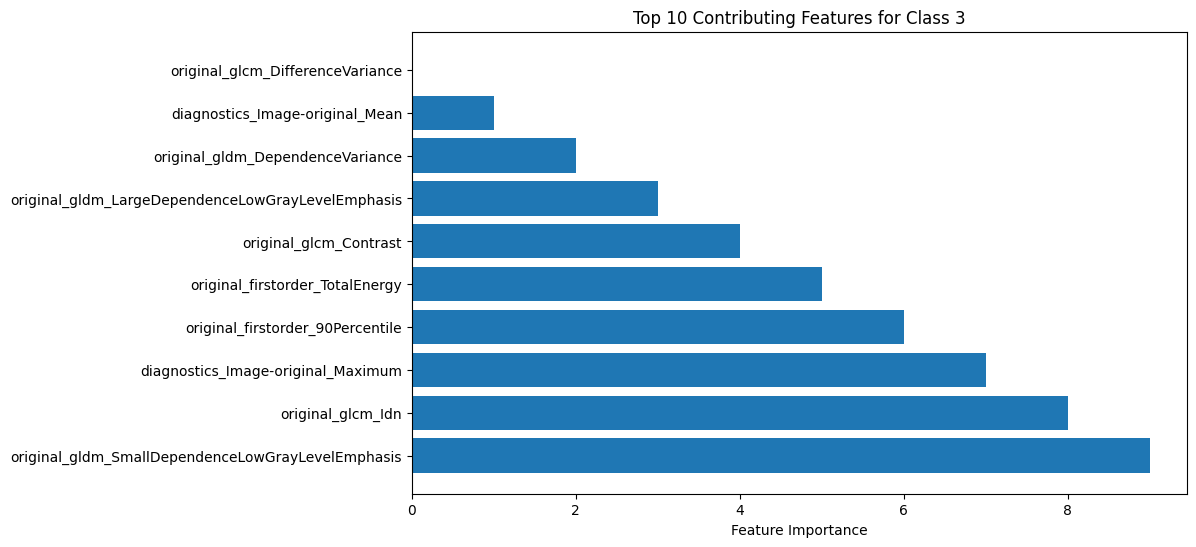

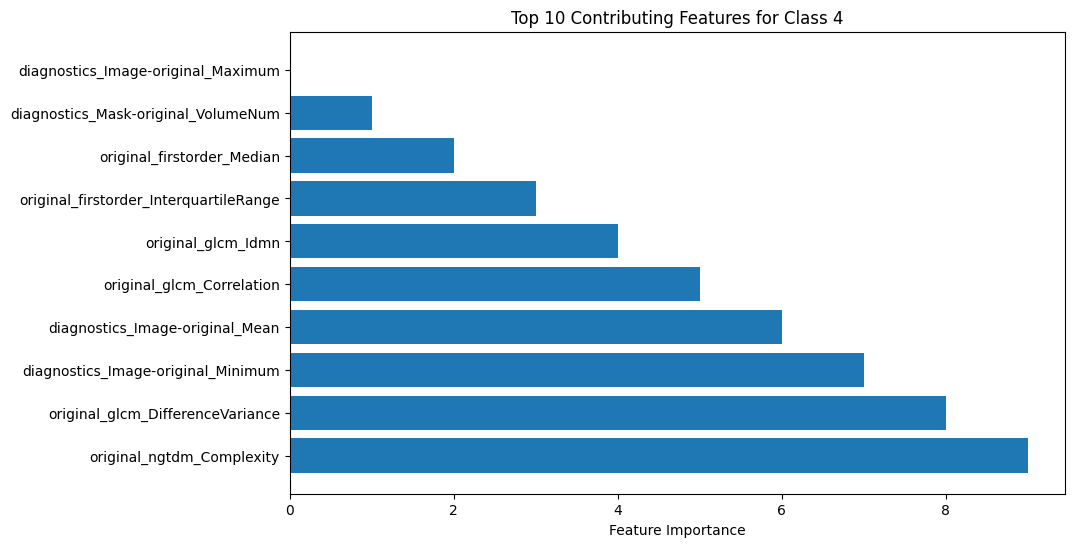

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the top 10 features for each class
top_features_dict = {
    0: [
        'diagnostics_Image-original_Minimum',
        'original_gldm_DependenceVariance',
        'original_glszm_SmallAreaLowGrayLevelEmphasis',
        'original_gldm_GrayLevelNonUniformity',
        'diagnostics_Image-original_Mean',
        'original_glszm_LargeAreaEmphasis',
        'original_glcm_Imc1',
        'original_glszm_LowGrayLevelZoneEmphasis',
        'original_glszm_LargeAreaHighGrayLevelEmphasis',
        'original_glszm_LargeAreaLowGrayLevelEmphasis'
    ],
    1: [
        'diagnostics_Image-original_Mean',
        'original_firstorder_90Percentile',
        'original_firstorder_Maximum',
        'original_glcm_MCC',
        'original_glcm_InverseVariance',
        'original_glcm_ClusterTendency',
        'diagnostics_Image-original_Maximum',
        'original_glszm_LargeAreaLowGrayLevelEmphasis',
        'original_glrlm_RunEntropy',
        'original_firstorder_TotalEnergy'
    ],
    2: [
        'diagnostics_Image-original_Mean',
        'original_glcm_DifferenceVariance',
        'diagnostics_Image-original_Maximum',
        'original_ngtdm_Busyness',
        'original_firstorder_Skewness',
        'original_gldm_SmallDependenceLowGrayLevelEmphasis',
        'original_firstorder_Range',
        'original_glcm_JointEnergy',
        'original_gldm_DependenceVariance',
        'original_glrlm_RunVariance'
    ],
    3: [
        'original_glcm_DifferenceVariance',
        'diagnostics_Image-original_Mean',
        'original_gldm_DependenceVariance',
        'original_gldm_LargeDependenceLowGrayLevelEmphasis',
        'original_glcm_Contrast',
        'original_firstorder_TotalEnergy',
        'original_firstorder_90Percentile',
        'diagnostics_Image-original_Maximum',
        'original_glcm_Idn',
        'original_gldm_SmallDependenceLowGrayLevelEmphasis'
    ],
    4: [
        'diagnostics_Image-original_Maximum',
        'diagnostics_Mask-original_VolumeNum',
        'original_firstorder_Median',
        'original_firstorder_InterquartileRange',
        'original_glcm_Idmn',
        'original_glcm_Correlation',
        'diagnostics_Image-original_Mean',
        'diagnostics_Image-original_Minimum',
        'original_glcm_DifferenceVariance',
        'original_ngtdm_Complexity'
    ]
}

# Function to plot top features for a given class
def plot_top_features(class_index, features):
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(features))
    plt.barh(y_pos, range(len(features)), align='center')
    plt.yticks(y_pos, features)
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Contributing Features for Class {class_index}')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
    plt.show()

# Plot top features for each class
for class_index, features in top_features_dict.items():
    plot_top_features(class_index, features)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import numpy as np

# Load the data
data = pd.read_csv('/content/drive/MyDrive/combined-features.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print(data['class-label'].value_counts())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Train an XGBoost classifier
model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Iterate over classes and print top 10 contributing features
for class_index in range(shap_values.shape[2]):
    print(f"Top 10 contributing features for class {class_index}:")

    # Select SHAP values for the current class
    class_shap_values = shap_values[:,:,class_index]

    # Calculate mean absolute SHAP values for each feature
    mean_abs_shap_values = np.mean(np.abs(class_shap_values), axis=0)

    # Get feature names sorted by mean absolute SHAP value
    top_feature_indices = np.argsort(mean_abs_shap_values)[-10:][::-1]
    top_features = X.columns[top_feature_indices]

    for feature in top_features:
        print(f"- {feature}")
    print("\n")

# SHAP Force plot for a single prediction (for the first class)
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0,:,0], X_test[0], feature_names=X.columns)


class-label
1    553
2    428
4    215
3    148
0    105
Name: count, dtype: int64
class-label
1    553
2    428
4    215
3    148
0    105
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       111
           1       0.84      0.85      0.85       110
           2       0.92      0.87      0.89       111
           3       0.95      0.94      0.95       111
           4       0.95      0.96      0.96       110

    accuracy                           0.92       553
   macro avg       0.92      0.92      0.92       553
weighted avg       0.92      0.92      0.92       553

[[110   1   0   0   0]
 [  3  94   6   4   3]
 [  1  11  97   1   1]
 [  1   5   0 104   1]
 [  0   1   3   0 106]]
Top 10 contributing features for class 0:
- diagnostics_Image-original_Minimum
- original_gldm_DependenceVariance
- original_glszm_SmallAreaLowGrayLevelEmphasis
- original_gldm_GrayLevelNonUniformity
- diagnostics_Image-original_

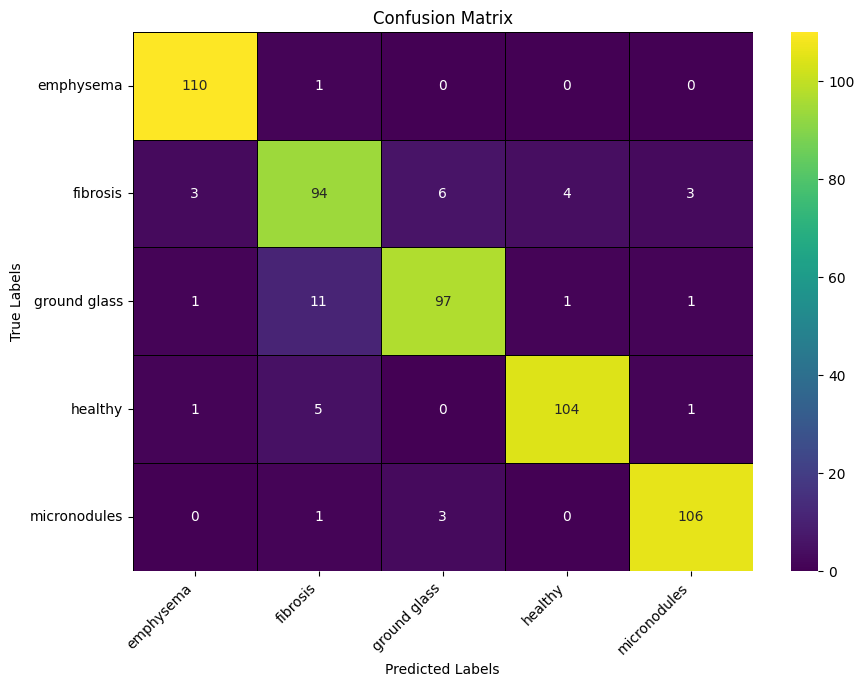

In [ ]:
[[111   0   0   0   0]
 [  1  95   7   4   3]
 [  1   8  99   1   2]
 [  0   3   1 105   2]
 [  0   1   3   0 106]]

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# Load the data
data = pd.read_csv('/content/drive/MyDrive/combined-features.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print(data['class-label'].value_counts())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Train an XGBoost classifier
model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Iterate over classes and plot dependence plots
for class_index in range(shap_values.shape[2]):
    # Select SHAP values for the current class
    class_shap_values = shap_values[:,:,class_index]

    # Plot SHAP dependence plots for all features for the current class
    for feature_name in X.columns:
        shap.dependence_plot(feature_name, class_shap_values, X_test, feature_names=X.columns, show=False)

# SHAP Force plot for a single prediction (for the first class)
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0,:,0], X_test[0], feature_names=X.columns)

In [ ]:
print(X.columns)


Index(['diagnostics_Image-original_Mean', 'diagnostics_Image-original_Minimum',
       'diagnostics_Image-original_Maximum',
       'diagnostics_Mask-original_VoxelNum',
       'diagnostics_Mask-original_VolumeNum',
       'original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_Entropy',
       'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       'original_firstorder_Range',
       'original_firstorder_RobustMeanAbsoluteDeviation',
       'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness',
       'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity',
       'original_firstorder_Variance', 'original_glcm_Autocorrelation',
       'original_glcm_ClusterProminence', 'origina

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RF- with out feature selection

In [ ]:
pip install lightgbm scikit-learn pandas


In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = '/content/drive/MyDrive/combined-features.csv'
data = pd.read_csv(file_path)

# Assuming the target column is named 'target', adjust as necessary
target_column = 'class-label'

# Encode the target variable if it's categorical
label_encoder = LabelEncoder()
data[target_column] = label_encoder.fit_transform(data[target_column])

# Split the dataset into features and target
X = data.drop(columns=[target_column])
y = data[target_column]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create the LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define the parameters for the model
params = {
    'objective': 'multiclass',  # For multi-class classification
    'num_class': len(label_encoder.classes_),  # Number of classes
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# Define early stopping callback
early_stopping_callback = lgb.early_stopping(stopping_rounds=10)

# Train the model
num_round = 100
bst = lgb.train(
    params,
    train_data,
    num_round,
    valid_sets=[test_data],
    callbacks=[early_stopping_callback]
)

# Predict on the test set
y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)
y_pred_max = [list(x).index(max(x)) for x in y_pred]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_max)
report = classification_report(y_test, y_pred_max, target_names=[str(cls) for cls in label_encoder.classes_])
conf_matrix = confusion_matrix(y_test, y_pred_max)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print('Confusion Matrix:')
print(conf_matrix)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23360
[LightGBM] [Info] Number of data points in the train set: 1155, number of used features: 93
[LightGBM] [Info] Start training from score -2.621039
[LightGBM] [Info] Start training from score -0.962811
[LightGBM] [Info] Start training from score -1.222910
[LightGBM] [Info] Start training from score -2.281171
[LightGBM] [Info] Start training from score -1.904361
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[64]	valid_0's multi_logloss: 0.573468
Accuracy: 0.8166089965397924
Classification Report:
              precision    re

In [ ]:
pip install imbalanced-learn


In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Load the dataset
file_path = '/content/drive/MyDrive/combined-features.csv'
data = pd.read_csv(file_path)

# Assuming the target column is named 'class-label', adjust as necessary
target_column = 'class-label'

# Encode the target variable if it's categorical
label_encoder = LabelEncoder()
data[target_column] = label_encoder.fit_transform(data[target_column])

# Split the dataset into features and target
X = data.drop(columns=[target_column])
y = data[target_column]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Create the LightGBM dataset
train_data = lgb.Dataset(X_train_smote, label=y_train_smote)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define the parameters for the model
params = {
    'objective': 'multiclass',  # For multi-class classification
    'num_class': len(label_encoder.classes_),  # Number of classes
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# Define early stopping callback
early_stopping_callback = lgb.early_stopping(stopping_rounds=10)

# Train the model
num_round = 100
bst = lgb.train(
    params,
    train_data,
    num_round,
    valid_sets=[test_data],
    callbacks=[early_stopping_callback]
)

# Predict on the test set
y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)
y_pred_max = [list(x).index(max(x)) for x in y_pred]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_max)
report = classification_report(y_test, y_pred_max, target_names=[str(cls) for cls in label_encoder.classes_])
conf_matrix = confusion_matrix(y_test, y_pred_max)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print('Confusion Matrix:')
print(conf_matrix)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23511
[LightGBM] [Info] Number of data points in the train set: 2205, number of used features: 93
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[86]	valid_0's multi_logloss: 0.588648
Accuracy: 0.7958477508650519
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.67      0.76        21
           1       0.82      0.78      0.80       110
           2       0.78    

In [ ]:
pip install scikit-learn pandas


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = '/content/drive/MyDrive/combined-features.csv'
data = pd.read_csv(file_path)

# Assuming the target column is named 'target', adjust as necessary
target_column = 'class-label'

# Encode the target variable if it's categorical
label_encoder = LabelEncoder()
data[target_column] = label_encoder.fit_transform(data[target_column])

# Split the dataset into features and target
X = data.drop(columns=[target_column])
y = data[target_column]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=[str(cls) for cls in label_encoder.classes_])
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print('Confusion Matrix:')
print(conf_matrix)


Accuracy: 0.7854671280276817
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        21
           1       0.79      0.81      0.80       110
           2       0.74      0.86      0.80        85
           3       0.82      0.77      0.79        30
           4       0.76      0.65      0.70        43

    accuracy                           0.79       289
   macro avg       0.82      0.75      0.78       289
weighted avg       0.79      0.79      0.78       289

Confusion Matrix:
[[14  6  0  0  1]
 [ 0 89 16  1  4]
 [ 0  7 73  3  2]
 [ 0  3  2 23  2]
 [ 0  7  7  1 28]]


In [ ]:
pip install xgboost scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 MB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.3.1+cu121 requires nvidia-cublas-cu12==12.1.3.1; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cuda-cupti-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cuda-nvrtc-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cuda-runtime-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cudnn-cu12==8.9.2.26; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requ

In [ ]:
pip install xgboost --upgrade


In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = '/content/drive/MyDrive/combined-features.csv'
data = pd.read_csv(file_path)

# Assuming the target column is named 'target', adjust as necessary
target_column = 'class-label'

# Encode the target variable if it's categorical
label_encoder = LabelEncoder()
data[target_column] = label_encoder.fit_transform(data[target_column])

# Split the dataset into features and target
X = data.drop(columns=[target_column])
y = data[target_column]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert the data into DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define the parameters for the model
params = {
    'objective': 'multi:softprob',  # For multi-class classification
    'num_class': len(label_encoder.classes_),  # Number of classes
    'eval_metric': 'mlogloss',
    'eta': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Train the model with early stopping
num_rounds = 100
evals = [(dtrain, 'train'), (dtest, 'eval')]
bst = xgb.train(params, dtrain, num_rounds, evals, early_stopping_rounds=10, verbose_eval=True)

# Predict on the test set
y_pred_prob = bst.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=[str(cls) for cls in label_encoder.classes_])
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print('Confusion Matrix:')
print(conf_matrix)


[0]	train-mlogloss:1.47698	eval-mlogloss:1.50685
[1]	train-mlogloss:1.36831	eval-mlogloss:1.42325
[2]	train-mlogloss:1.27204	eval-mlogloss:1.34297


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:723: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[3]	train-mlogloss:1.18685	eval-mlogloss:1.27843
[4]	train-mlogloss:1.10840	eval-mlogloss:1.22321
[5]	train-mlogloss:1.03810	eval-mlogloss:1.16618
[6]	train-mlogloss:0.97586	eval-mlogloss:1.11875
[7]	train-mlogloss:0.91999	eval-mlogloss:1.07823
[8]	train-mlogloss:0.86826	eval-mlogloss:1.04302
[9]	train-mlogloss:0.81881	eval-mlogloss:1.00401
[10]	train-mlogloss:0.77327	eval-mlogloss:0.97412
[11]	train-mlogloss:0.73402	eval-mlogloss:0.94818
[12]	train-mlogloss:0.69628	eval-mlogloss:0.92017
[13]	train-mlogloss:0.66085	eval-mlogloss:0.89558
[14]	train-mlogloss:0.62857	eval-mlogloss:0.87292
[15]	train-mlogloss:0.60095	eval-mlogloss:0.85384
[16]	train-mlogloss:0.56899	eval-mlogloss:0.83320
[17]	train-mlogloss:0.53907	eval-mlogloss:0.81533
[18]	train-mlogloss:0.51585	eval-mlogloss:0.80010
[19]	train-mlogloss:0.49285	eval-mlogloss:0.78690
[20]	train-mlogloss:0.47195	eval-mlogloss:0.77284
[21]	train-mlogloss:0.45229	eval-mlogloss:0.76089
[22]	train-mlogloss:0.43218	eval-mlogloss:0.74743
[23]	tr

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load the data
data = pd.read_csv('/content/drive/MyDrive/combined-features.csv')

data.shape

(1444, 94)

In [ ]:
data.head()

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,class-label
0,0.0,750.0,14524323,3.256302,325.00,5.220349,1422,274.677500,227.037500,29.0,...,0.056061,4.684184,0.500000,33.300000,0.322475,0.017466,3481.710994,3.372400,82.770409,0
1,0.0,464.0,6902427,3.014118,229.25,4.178773,746,160.434156,137.456897,0.0,...,0.028963,4.683074,0.431034,70.417600,1.364870,0.007877,1974.196790,1.144792,17.026466,0
2,0.0,487.0,178880375,3.870999,269.75,6.583731,1331,178.413492,178.130029,86.0,...,0.040350,5.512989,0.542689,304.821542,4.796281,0.000722,7964.958636,0.332250,6.658040,0
3,0.0,301.4,275753234,3.270713,160.00,10.179898,1222,113.815855,107.419107,42.0,...,0.050516,5.183765,0.456738,573.206642,22.943388,0.000188,5558.914584,0.137467,1.874385,0
4,0.0,248.0,420115326,3.139476,126.00,16.807075,1441,98.982617,93.386067,37.0,...,0.061740,5.190732,0.435731,1017.635307,23.689049,0.000141,7229.887941,0.065232,2.691076,0


In [ ]:
# separate train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['class-label'], axis=1),
    data['class-label'],
    test_size=0.2,
    random_state=0)

X_train.shape, X_test.shape

((1155, 93), (289, 93))

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:

# altogether in one line of code

# first I specify the Logistic Regression model, and I
# make sure I select the Lasso (l1) penalty.

# Then I use the selectFromModel class from sklearn, which
# will select the features which coefficients are non-zero
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
sel_ = SelectFromModel(
    LogisticRegression(C=0.5, penalty='l1', solver='liblinear', random_state=10))

sel_.fit(scaler.transform(X_train), y_train)

SelectFromModel(estimator=LogisticRegression(C=0.5, penalty='l1',
                                             random_state=10,
                                             solver='liblinear'))

In [ ]:
ch = sel_.get_support()
len(sel_.get_support())

93

In [ ]:
names = X_train.columns.tolist()

In [ ]:
selected_features = [v for i,v in enumerate(names) if ch[i] == True]

In [ ]:
ch

array([False,  True,  True, False,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True, False,  True,  True,  True,  True,
       False, False,  True,  True,  True,  True,  True, False,  True,
       False,  True, False, False,  True,  True,  True, False,  True,
        True,  True, False, False, False,  True, False,  True, False,
        True,  True,  True,  True, False, False, False, False,  True,
       False,  True, False, False, False,  True,  True, False,  True,
        True, False,  True, False,  True,  True,  True,  True,  True,
       False, False, False,  True, False, False,  True,  True,  True,
        True,  True,  True])

In [ ]:
# Now I make a list with the selected features
import numpy as np
selected_feat = X_train.columns[(sel_.get_support())]

print('total features: {}'.format((X_train.shape[1])))
print('selected features: {}'.format(len(selected_feat)))
print('features with coefficients shrank to zero: {}'.format(
    np.sum(sel_.estimator_.coef_ == 0)))

total features: 93
selected features: 59
features with coefficients shrank to zero: 329


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
rf = RandomForestClassifier(n_estimators=50,
                            max_depth=4,
                            random_state=50,
                            n_jobs=4)

rf.fit(X_train[selected_features], y_train)

# print roc-auc in train and testing sets
print(
    'train auc score: ',
    roc_auc_score(y_train, (rf.predict_proba(X_train[selected_features])), multi_class='ovo'))
print(
    'test auc score: ',
    roc_auc_score(y_test, (rf.predict_proba(X_test[selected_features])), multi_class='ovo'))

train auc score:  0.9003692998764794
test auc score:  0.8305614642285903


In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = rf.predict(X_test[selected_features])

# Create and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[ 4 17  5  0  2]
 [ 0 89 13  2  6]
 [ 0 35 40  1  0]
 [ 0  2 11 19  2]
 [ 0 13 16  2 10]]


In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Define the number of classes
num_classes = 5

# Load and prepare the data (assuming X_test and model are already defined)
# Example of loading the model and data
# model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
# model.fit(X_train, y_train)
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plots for each class
for class_index in range(num_classes):
    # Extract SHAP values for the current class
    class_shap_values = shap_values[class_index]

    # Create a DataFrame with the SHAP values and feature names
    # Use top_features for column names instead of X.columns
    shap_df = pd.DataFrame(class_shap_values, columns=top_features)  # Changed line

    # Calculate mean absolute SHAP values to determine feature importance
    mean_shap_values = shap_df.abs().mean().sort_values(ascending=False)
    top_features = mean_shap_values.head(10).index

    # Convert top_features to a list for NumPy indexing
    top_feature_names = top_features.tolist()

    # Filter SHAP values and X_test for top features
    top_shap_values = class_shap_values[:, top_feature_names] # Use the list here
    X_test_top = X_test[:, top_feature_names] # And here

    # Plot SHAP summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(class_shap_values[:, top_feature_names], X_test[:, top_feature_names], feature_names=top_feature_names)
    plt.title(f'SHAP Summary Plot for Class {class_index}')
    plt.savefig(f'shap_summary_class_{class_index}.png')
    plt.close()

    # Plot SHAP dependence plots for top features
    for feature_name in top_feature_names: # Iterate over the list
        plt.figure(figsize=(12, 8))
        shap.dependence_plot(feature_name, class_shap_values, X_test, feature_names=X.columns)
        plt.title(f'SHAP Dependence Plot for {feature_name} - Class {class_index}')
        plt.savefig(f'shap_dependence_{feature_name}_class_{class_index}.png')
        plt.close()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the data
data = pd.read_csv('/content/drive/MyDrive/combined-features.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Initialize classifiers for ensemble methods
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Voting Classifier
voting_clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb), ('xgb', xgb_model)], voting='soft')
voting_clf.fit(X_train, y_train)

# Stacking Classifier with Logistic Regression as a meta-classifier
stacking_clf = StackingClassifier(estimators=[('rf', rf), ('gb', gb), ('xgb', xgb_model)], final_estimator=LogisticRegression(), cv=5)
stacking_clf.fit(X_train, y_train)



# Evaluate the models
print("Voting Classifier Results:")
y_pred_voting = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred_voting))
print(confusion_matrix(y_test, y_pred_voting))

print("Stacking Classifier Results:")
y_pred_stacking = stacking_clf.predict(X_test)
print(classification_report(y_test, y_pred_stacking))
print(confusion_matrix(y_test, y_pred_stacking))


class-label
1    553
2    428
4    215
3    148
0    105
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:54:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:55:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:59:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:59:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:59:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Voting Classifier Results:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       111
           1       0.85      0.86      0.86       110
           2       0.90      0.86      0.88       111
           3       0.95      0.94      0.94       111
           4       0.94      0.94      0.94       110

    accuracy                           0.92       553
   macro avg       0.92      0.92      0.92       553
weighted avg       0.92      0.92      0.92       553

[[111   0   0   0   0]
 [  1  95   7   4   3]
 [  1  10  96   2   2]
 [  1   4   0 104   2]
 [  0   3   4   0 103]]
Stacking Classifier Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       111
           1       0.89      0.86      0.88       110
           2       0.90      0.89      0.90       111
           3       0.95      0.95      0.95       111
           4       0.94      0.96      0.95       110

    accuracy 

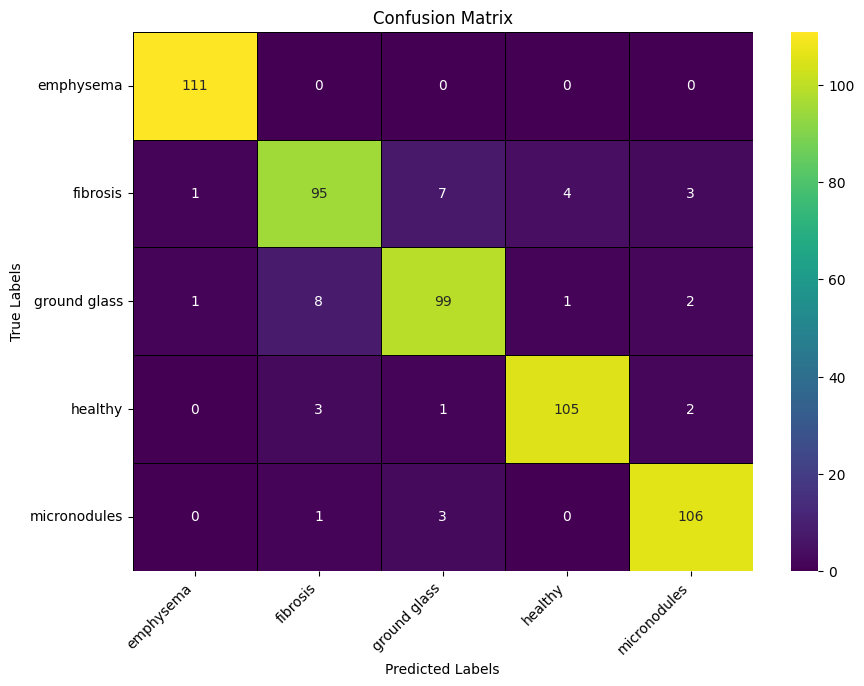

In [ ]:
import matplotlib.pyplot as plt
# Define the confusion matrix
cm = np.array([[111,   0,   0,   0,   0],
               [  1,  95,   7,   4,   3],
               [  1,   8,  99,   1,   2],
               [  0,   3,   1, 105,   2],
               [  0,   1,   3,   0, 106]])

# Define class names corresponding to the labels
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']

# Plot the confusion matrix with class names
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black', cbar=True)

# Add labels, title, and set class names on the axes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the data
data = pd.read_csv('/content/drive/MyDrive/combined-features.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Deep Learning Model (Simple MLP)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

print("Deep Learning Model Results:")
y_pred_dl = model.predict(X_test)
y_pred_dl = y_pred_dl.argmax(axis=1)
print(classification_report(y_test, y_pred_dl))
print(confusion_matrix(y_test, y_pred_dl))


class-label
1    553
2    428
4    215
3    148
0    105
Name: count, dtype: int64
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3401 - loss: 1.5544 - val_accuracy: 0.6479 - val_loss: 1.0531
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5773 - loss: 1.1132 - val_accuracy: 0.6479 - val_loss: 0.8991
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6131 - loss: 0.9856 - val_accuracy: 0.6840 - val_loss: 0.7892
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6478 - loss: 0.9162 - val_accuracy: 0.7133 - val_loss: 0.7296
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6812 - loss: 0.8261 - val_accuracy: 0.6907 - val_loss: 0.7057
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7071 - loss: 0.7962 - val_accuracy: 0.7404 - val_loss: 0.6569
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7023 - loss: 0.7440 - val_accuracy: 0.7427 - val_loss: 0.6206
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7170 - loss: 0.7160 - val_accuracy: 0.7675 - val_loss: 0.6

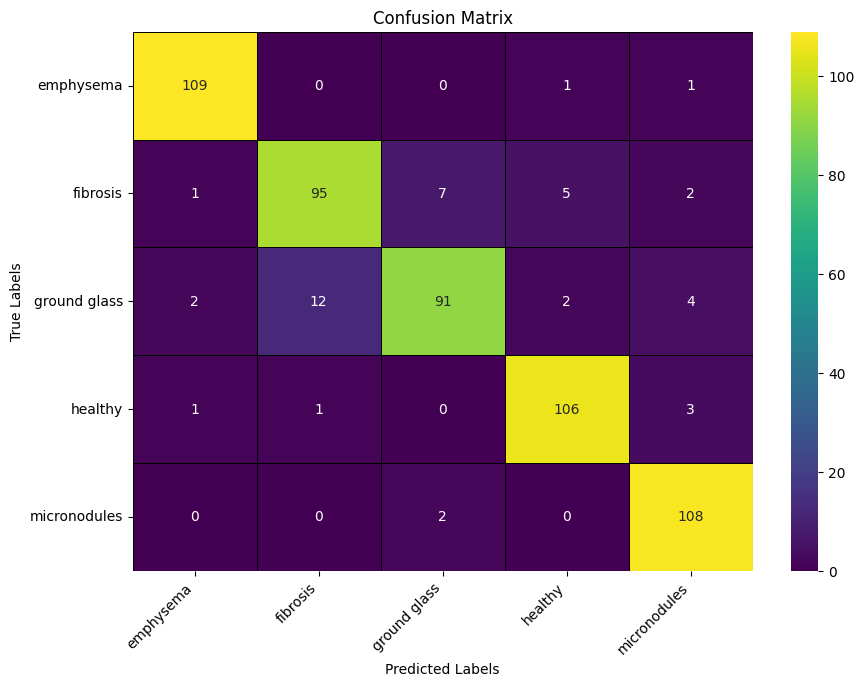

In [ ]:
# Define the confusion matrix
cm = np.array([[109,   0,   0,   1,   1],
               [  1,  95,   7,   5,   2],
               [  2,  12,  91,   2,   4],
               [  1,   1,   0, 106,   3],
               [  0,   0,   2,   0, 108]])

# Define class names corresponding to the labels
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']

# Plot the confusion matrix with class names
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black', cbar=True)

# Add labels, title, and set class names on the axes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.show()


Feature fusion

In [ ]:
import pandas as pd

# Load the two CSV files
radiomics_df = pd.read_csv('/content/drive/MyDrive/combined-features.csv')
vit_df = pd.read_csv('/content/drive/MyDrive/vitfeat.csv')

# Ensure that the rows correspond correctly
combined_df = pd.concat([radiomics_df, vit_df], axis=1)

# Save the combined features to a new CSV file
combined_df.to_csv('/content/drive/MyDrive/rad-vit.csv', index=False)


In [ ]:
# Load the data
data = pd.read_csv('/content/drive/MyDrive/rad-vit.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Check for and handle missing values in 'y'
print("Number of missing values in 'y':", y.isna().sum())
y = y.fillna(y.mode()[0])  # Fill missing values with the most frequent class

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Deep Learning Model (Simple MLP)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

print("Deep Learning Model Results:")
y_pred_dl = model.predict(X_test)
y_pred_dl = y_pred_dl.argmax(axis=1)
print(classification_report(y_test, y_pred_dl))
print(confusion_matrix(y_test, y_pred_dl))

class-label
1.0    553
2.0    428
4.0    215
3.0    148
0.0    105
Name: count, dtype: int64
Number of missing values in 'y': 42


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4511 - loss: 1.6705 - val_accuracy: 0.8697 - val_loss: 0.3949
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8052 - loss: 0.5460 - val_accuracy: 0.9118 - val_loss: 0.2286
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8819 - loss: 0.3263 - val_accuracy: 0.9412 - val_loss: 0.1651
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9187 - loss: 0.2227 - val_accuracy: 0.9559 - val_loss: 0.1213
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9357 - loss: 0.1770 - val_accuracy: 0.9622 - val_loss: 0.0871
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9593 - loss: 0.1114 - val_accuracy: 0.9727 - val_loss: 0.0713
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9549 - loss: 0.1138 - val_accuracy: 0.9622 - val_loss: 0.0790
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9738 - loss: 0.0936 - val_accuracy: 0.962

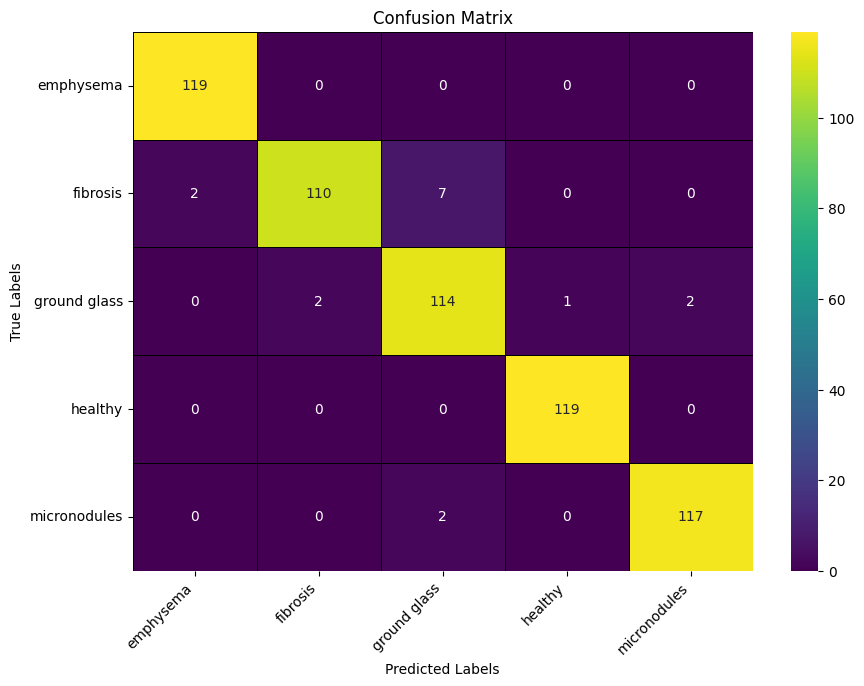

In [ ]:
# Define the confusion matrix
cm = np.array([[119,   0,   0,   0,   0],
               [  2, 110,   7,   0,   0],
               [  0,   2, 114,   1,   2],
               [  0,   0,   0, 119,   0],
               [  0,   0,   2,   0, 117]])

# Define class names corresponding to the labels
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']

# Plot the confusion matrix with class names
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black', cbar=True)

# Add labels, title, and set class names on the axes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load the data
data = pd.read_csv('/content/drive/MyDrive/rad-vit.csv')

# Inspect the class distribution
print(data['class-label'].value_counts())

# Separate features and labels
X = data.drop('class-label', axis=1)
y = data['class-label']

# Remove non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
X = X.drop(non_numeric_columns, axis=1)

# Handle missing values if necessary
# Example: Fill missing values with the mean
X = X.fillna(X.mean())

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Number of missing values in 'y':", y.isna().sum())
y = y.fillna(y.mode()[0])
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
# Initialize classifiers for ensemble methods
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
# Stacking Classifier with Logistic Regression as a meta-classifier
stacking_clf = StackingClassifier(estimators=[('rf', rf), ('gb', gb), ('xgb', xgb_model)], final_estimator=LogisticRegression(), cv=5)
stacking_clf.fit(X_train, y_train)
print("Stacking Classifier Results:")
y_pred_stacking = stacking_clf.predict(X_test)
print(classification_report(y_test, y_pred_stacking))
print(confusion_matrix(y_test, y_pred_stacking))


class-label
1.0    553
2.0    428
4.0    215
3.0    148
0.0    105
Name: count, dtype: int64
Number of missing values in 'y': 42


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [08:59:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [10:36:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [10:37:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [10:38:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [10:39:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Stacking Classifier Results:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       119
         1.0       0.97      0.99      0.98       119
         2.0       1.00      0.97      0.98       119
         3.0       1.00      1.00      1.00       119
         4.0       1.00      1.00      1.00       119

    accuracy                           0.99       595
   macro avg       0.99      0.99      0.99       595
weighted avg       0.99      0.99      0.99       595

[[119   0   0   0   0]
 [  1 118   0   0   0]
 [  0   4 115   0   0]
 [  0   0   0 119   0]
 [  0   0   0   0 119]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Function to plot the learning curve
def plot_learning_curve(estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'):
    plt.figure(figsize=(10, 6))

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                                                            train_sizes=train_sizes, scoring=scoring)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation score")

    plt.title("Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot learning curve for the stacking classifier
plot_learning_curve(stacking_clf, X_resampled, y_resampled, cv=5, scoring='accuracy')

# Check for overfitting by comparing training and validation scores
train_score = stacking_clf.score(X_train, y_train)
test_score = stacking_clf.score(X_test, y_test)

print(f"Training Score: {train_score}")
print(f"Test Score: {test_score}")

if train_score > test_score:
    print("The model may be overfitting. Consider regularization or other techniques to improve generalization.")
else:
    print("The model is not overfitting. The training and test scores are comparable.")


NameError: name 'stacking_clf' is not defined

ROC AUC Curve for Stacking Classifier


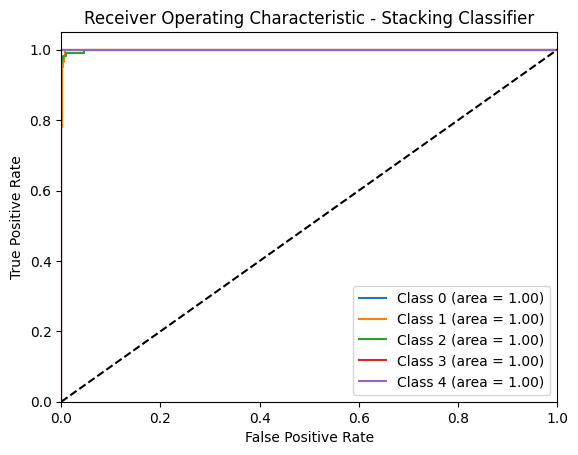

Learning Curve for Stacking Classifier


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [07:43:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [07:49:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [07:49:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [07:49:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [07:50:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import learning_curve
import numpy as np

# Generate ROC AUC curve for the Stacking Classifier
def plot_roc_auc_curve(model, X_test, y_test, model_name):
    y_proba = model.predict_proba(X_test)
    n_classes = len(np.unique(y_test))

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve
    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {model_name}')
    plt.legend(loc='lower right')
    plt.show()

# Plot learning curve for the Stacking Classifier
def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.grid()

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

# Evaluate and plot ROC AUC for Stacking Classifier
print("ROC AUC Curve for Stacking Classifier")
plot_roc_auc_curve(stacking_clf, X_test, y_test, "Stacking Classifier")

# Plot learning curve for Stacking Classifier
print("Learning Curve for Stacking Classifier")
plot_learning_curve(stacking_clf, "Learning Curve - Stacking Classifier", X_train, y_train)



In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Function to print accuracy metrics
def print_accuracy_metrics(model, X_train, y_train, X_test, y_test):
    # Training Accuracy
    y_train_pred = model.predict(X_train)
    training_accuracy = accuracy_score(y_train, y_train_pred)

    # Test Accuracy
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Training Accuracy: {training_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

# Compute cross-validation scores
def print_cv_scores(model, X, y, cv=5):
    cv_scores = cross_val_score(model, X, y, cv=cv)
    print(f"Cross-Validation Scores: {cv_scores}")
    print(f"Mean Cross-Validation Score: {np.mean(cv_scores):.4f}")
    print(f"Standard Deviation of Cross-Validation Scores: {np.std(cv_scores):.4f}")

# Fit the stacking classifier
stacking_clf.fit(X_train, y_train)

# Print accuracy metrics
print("Stacking Classifier Results:")
print_accuracy_metrics(stacking_clf, X_train, y_train, X_test, y_test)

# Print cross-validation scores
print("\nCross-Validation Results:")
print_cv_scores(stacking_clf, X_resampled, y_resampled)


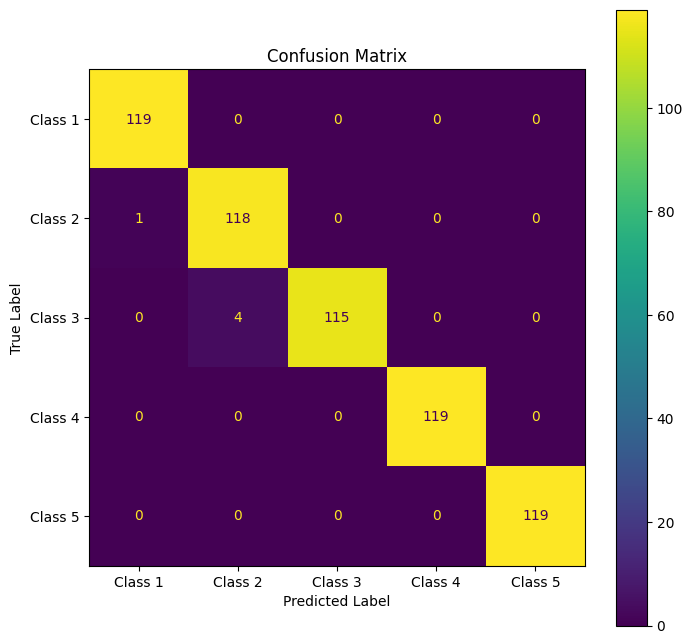

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix data
conf_matrix = np.array([[119,   0,   0,   0,   0],
                        [  1, 118,   0,   0,   0],
                        [  0,   4, 115,   0,   0],
                        [  0,   0,   0, 119,   0],
                        [  0,   0,   0,   0, 119]])

# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5'])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='viridis', values_format='d')

# Customize plot
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Show the plot
plt.show()


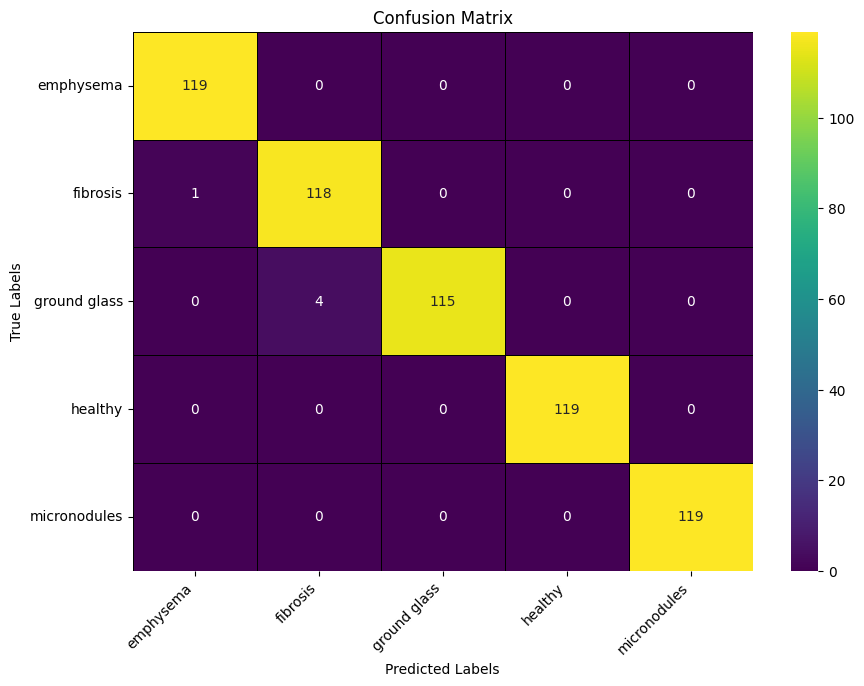

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix data
cm = np.array([[119,   0,   0,   0,   0],
                        [  1, 118,   0,   0,   0],
                        [  0,   4, 115,   0,   0],
                        [  0,   0,   0, 119,   0],
                        [  0,   0,   0,   0, 119]])

# Class labels
class_names = ['emphysema', 'fibrosis', 'ground glass', 'healthy', 'micronodules']
# Plot the confusion matrix with class names
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='black', cbar=True)

# Add labels, title, and set class names on the axes
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0)

plt.show()

